# Sentinel-2 fire imagery from CDSE — educational daily-acquisition workflow

This notebook combines the two supplied CDSE notebooks while deliberately keeping the **standard date-based processing logic** rather than grouping imagery into overpasses.

## What the notebook does

1. Connects to the Copernicus Data Space Ecosystem (CDSE) Sentinel Hub services.
2. Reads an AOI from a GIS file already stored in `mystorage` (GeoPackage, GeoJSON, Shapefile, etc.).
3. Optionally buffers the AOI in **metres**, then derives the WGS84 processing bounding box automatically.
4. Searches the Sentinel-2 L1C catalogue for the chosen date range.
5. Lets you select acquisition **dates**, not overpasses.
6. Warns before processing more than 10 selected dates.
7. For each selected date, downloads the same products used in the supplied overpass notebook:
   - True Colour
   - QuickFire / Wildfire
   - SWIR composite
   - B12
   - B8A
   - NBR
   - metadata JSON
8. Stores each acquisition in:

   `mystorage/Sentinel-2/<PROJECT_NAME>/<YYYY-MM-DD>/`

9. Provides widget-based plotting of the downloaded products.
10. Lets you pick a pre-fire NBR image and calculates dNBR for every **later** processed date.
11. Names every dNBR file with **both** the pre-fire date and comparison date.

> **Important:** the processing request uses the rectangular bounding box derived from the AOI. It does not mask the returned TIFF to the exact polygon boundary.

The uploaded overpass notebook contains NBR as its quantitative index, together with B12 and B8A. This notebook mirrors those products rather than silently adding other indices.

## 1. Install the Python packages

Run this once in a new CDSE Jupyter environment. `geopandas` is used only to read and prepare the AOI; Sentinel Hub performs the image processing.

In [1]:
%pip install -q pandas matplotlib sentinelhub rasterio geopandas requests ipywidgets

Note: you may need to restart the kernel to use updated packages.


## 2. Imports

Most processing is done by the Sentinel Hub Process API. `rasterio` is used to add metadata and later calculate dNBR locally from the downloaded NBR rasters.

In [16]:
# Standard library
from datetime import datetime, timedelta
from pathlib import Path
import glob
import json
import math
import os
import shutil

# Third-party libraries
import geopandas as gpd
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import requests

from IPython.display import clear_output, display

# Sentinel Hub
from sentinelhub import (
    BBox,
    CRS,
    DataCollection,
    MimeType,
    MosaickingOrder,
    SentinelHubCatalog,
    SentinelHubRequest,
    SHConfig,
    bbox_to_dimensions,
)

## 3. CDSE Sentinel Hub credentials

Enter the OAuth client ID and client secret created for your CDSE account. `getpass` prevents the values from being printed in the notebook.

In [17]:
os.environ["CDSE_CLIENT_ID"] = "sh-f465562d-0f8b-45fa-a933-0a8812b16ca6"
os.environ["CDSE_CLIENT_SECRET"] = "RlYiHldUqa11Ve90xtqpMwJn9VojEP3H"

In [18]:
# Sentinel Hub / CDSE configuration
config = SHConfig()

config.sh_client_id = os.environ["CDSE_CLIENT_ID"]
config.sh_client_secret = os.environ["CDSE_CLIENT_SECRET"]

config.sh_token_url = (
    "https://identity.dataspace.copernicus.eu/"
    "auth/realms/CDSE/protocol/openid-connect/token"
)

config.sh_base_url = "https://sh.dataspace.copernicus.eu"

print("CDSE Sentinel Hub configuration is ready.")

CDSE Sentinel Hub configuration is ready.


## 4. Project settings

Edit this cell for each fire project.

### Folder structure

With `PROJECT_NAME = "ALB_WF001"`, the notebook will create:

```text
mystorage/
└── Sentinel-2/
    └── ALB_WF001/
        ├── 2026-08-08/
        ├── 2026-08-15/
        └── ...
```

### AOI files

A GeoPackage (`.gpkg`) or GeoJSON is easiest because it is a single file. A Shapefile also works, but its `.shp`, `.shx`, `.dbf`, `.prj`, etc. must remain together in the same directory.

In [19]:
# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

ROOT_FOLDER = Path(r"C:\iamo\fire-school")

PROJECT_NAME = "ALB_WF001"

MYSTORAGE_FOLDER = ROOT_FOLDER / "mystorage"
BASE_FOLDER = MYSTORAGE_FOLDER / "Sentinel-2"
PROJECT_FOLDER = BASE_FOLDER / PROJECT_NAME
CACHE_FOLDER = MYSTORAGE_FOLDER / "downloads"

# ------------------------------------------------------------
# AOI STORED ON CDSE
# ------------------------------------------------------------

# Examples:
# AOI_FILE = Path("mystorage/AOI/ALB_WF001.gpkg")
# AOI_FILE = Path("mystorage/AOI/ALB_WF001.geojson")
# AOI_FILE = Path("mystorage/AOI/ALB_WF001.shp")

AOI_FILE = Path(
    r"C:\iamo\fire-school\data\aoi\ALB_WF001_AOI.shp"
)

# For a multi-layer GeoPackage, enter the layer name.
# Leave as None for GeoJSON/Shapefile or a single-layer file.
AOI_LAYER = None

# Optional outward buffer around the AOI, in metres.
AOI_BUFFER_METERS = 0

# ------------------------------------------------------------
# DATE RANGE AND CATALOGUE FILTERING
# ------------------------------------------------------------

DATE_FROM = "2026-08-08"
DATE_TO   = "2026-08-23"

# None = no catalogue cloud filter.
# Example: 30 = retain catalogue items with <= 30% cloud cover.
MAX_CLOUD_PERCENT = None

# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------

RESOLUTION = 10
WARN_IF_MORE_THAN = 10

PROJECT_FOLDER.mkdir(parents=True, exist_ok=True)
CACHE_FOLDER.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_FOLDER)
print("AOI file:", AOI_FILE)

Project folder: C:\iamo\fire-school\mystorage\Sentinel-2\ALB_WF001
AOI file: C:\iamo\fire-school\data\aoi\ALB_WF001_AOI.shp


## 5. Read the AOI and derive the processing bbox

The workflow is:

1. Read the AOI file with GeoPandas.
2. Reproject it to WGS84 (`EPSG:4326`).
3. Dissolve all features into one geometry.
4. If requested, estimate a local projected CRS and buffer the geometry in metres.
5. Derive `[west, south, east, north]` from the resulting geometry.
6. Convert those bounds to a Sentinel Hub `BBox`.

This removes the need to copy coordinates manually from Copernicus Browser.

AOI CRS: EPSG:4326
Derived bbox [W, S, E, N]: [19.80504530113058, 41.896818246571, 20.0731613746381, 42.04425940374519]
Buffer (m): 0
Output size (pixels): (2242, 1610)


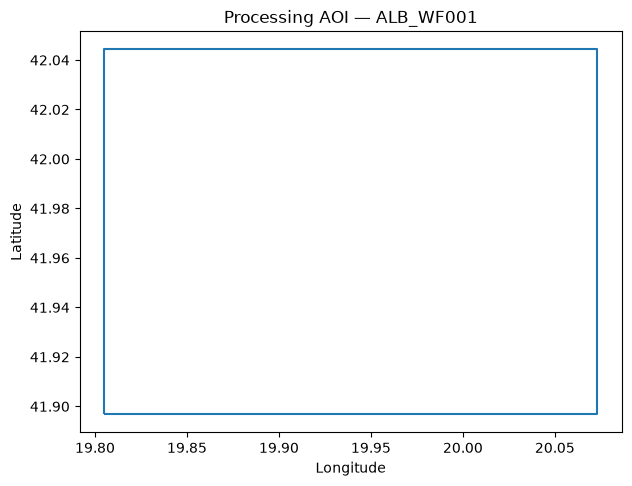

In [20]:
if not AOI_FILE.exists():
    raise FileNotFoundError(
        f"AOI file not found: {AOI_FILE}\n"
        "Upload/copy the AOI into mystorage and update AOI_FILE."
    )

read_kwargs = {}
if AOI_LAYER is not None:
    read_kwargs["layer"] = AOI_LAYER

aoi = gpd.read_file(AOI_FILE, **read_kwargs)

if aoi.empty:
    raise ValueError("The AOI file contains no features.")

if aoi.crs is None:
    raise ValueError(
        "The AOI has no CRS. Define the correct CRS in the GIS file before processing."
    )

# Remove empty geometries.
aoi = aoi[aoi.geometry.notna() & ~aoi.geometry.is_empty].copy()

if aoi.empty:
    raise ValueError("The AOI contains no usable geometries.")

# Work in WGS84 for Sentinel Hub catalogue/process requests.
aoi_wgs84 = aoi.to_crs("EPSG:4326")

# Dissolve multiple input features into one AOI geometry.
aoi_geometry = aoi_wgs84.geometry.union_all()
aoi_for_processing = gpd.GeoDataFrame(
    {"name": [PROJECT_NAME]},
    geometry=[aoi_geometry],
    crs="EPSG:4326",
)

# Buffer in a local metric CRS if requested.
if AOI_BUFFER_METERS > 0:
    metric_crs = aoi_for_processing.estimate_utm_crs()
    if metric_crs is None:
        raise RuntimeError("Could not estimate a suitable metric CRS for buffering.")

    aoi_metric = aoi_for_processing.to_crs(metric_crs)
    buffered_geometry = aoi_metric.geometry.iloc[0].buffer(AOI_BUFFER_METERS)
    aoi_for_processing = gpd.GeoDataFrame(
        {"name": [PROJECT_NAME]},
        geometry=[buffered_geometry],
        crs=metric_crs,
    ).to_crs("EPSG:4326")

west, south, east, north = aoi_for_processing.total_bounds
bbox_coords = [float(west), float(south), float(east), float(north)]

aoi_bbox = BBox(bbox=bbox_coords, crs=CRS.WGS84)
aoi_size = bbox_to_dimensions(aoi_bbox, resolution=RESOLUTION)

print("AOI CRS: EPSG:4326")
print("Derived bbox [W, S, E, N]:", bbox_coords)
print("Buffer (m):", AOI_BUFFER_METERS)
print("Output size (pixels):", aoi_size)

ax = aoi_for_processing.boundary.plot(figsize=(7, 7))
ax.set_title(f"Processing AOI — {PROJECT_NAME}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 6. Define the CDSE Sentinel-2 L1C collection

This matches the supplied notebooks: Sentinel-2 **L1C** imagery is requested through the CDSE Sentinel Hub endpoint.

In [21]:
s2_l1c_cdse = DataCollection.SENTINEL2_L1C.define_from(
    "s2l1c_cdse_daily_fire",
    service_url=config.sh_base_url,
)

print("Collection ready:", s2_l1c_cdse)

Collection ready: DataCollection.s2l1c_cdse_daily_fire


## 7. Load the Sentinel Hub visualization algorithms

Instead of copying long JavaScript evalscripts into the notebook, these visualization algorithms are loaded directly from the Sentinel Hub Custom Scripts repository at runtime.

The supplied overpass notebook uses:

- Sentinel-2 True Colour
- Copernicus Browser QuickFire / Wildfire (`markuse_fire/cdse.js`)
- Sentinel-2 SWIR RGB (`B12 / B8A / B04`)

This keeps the teaching notebook readable and makes the source of each visualization explicit.

In [22]:
def load_evalscript(url):
    """Download an evalscript as plain text and fail clearly if unavailable."""
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    return response.text


print("Loading Sentinel Hub visualization scripts...")

evalscript_true_colour = load_evalscript(
    "https://custom-scripts.sentinel-hub.com/"
    "custom-scripts/sentinel-2/true_color/script.js"
)

evalscript_wildfire = load_evalscript(
    "https://custom-scripts.sentinel-hub.com/"
    "custom-scripts/sentinel-2/markuse_fire/cdse.js"
)

evalscript_swir = load_evalscript(
    "https://custom-scripts.sentinel-hub.com/"
    "custom-scripts/sentinel-2/swir-rgb/script.js"
)

print("Visualization scripts loaded.")

Loading Sentinel Hub visualization scripts...
Visualization scripts loaded.


## 8. Define the quantitative products used in the supplied overpass notebook

The visual composites above are downloaded from Sentinel Hub's script library. The following small evalscripts request raw reflectance or calculate NBR:

- **B12** — SWIR2 reflectance
- **B8A** — narrow NIR reflectance
- **NBR** — `(B08 - B12) / (B08 + B12)`

`-9999` is used as output NoData for invalid pixels.

In [23]:
evalscript_b12 = r"""
//VERSION=3
function setup() {
    return {
        input: ["B12", "dataMask"],
        output: {bands: 1, sampleType: "FLOAT32"}
    };
}
function evaluatePixel(s) {
    if (!s.dataMask) return [-9999];
    return [s.B12];
}
"""


evalscript_b8a = r"""
//VERSION=3
function setup() {
    return {
        input: ["B8A", "dataMask"],
        output: {bands: 1, sampleType: "FLOAT32"}
    };
}
function evaluatePixel(s) {
    if (!s.dataMask) return [-9999];
    return [s.B8A];
}
"""


evalscript_nbr = r"""
//VERSION=3
function setup() {
    return {
        input: ["B08", "B12", "dataMask"],
        output: {bands: 1, sampleType: "FLOAT32"}
    };
}
function evaluatePixel(s) {
    if (!s.dataMask) return [-9999];
    let denominator = s.B08 + s.B12;
    if (denominator === 0) return [-9999];
    return [(s.B08 - s.B12) / denominator];
}
"""

## 9. Search the Sentinel-2 catalogue

We search all catalogue items intersecting the AOI during the requested date range, optionally filter them by catalogue cloud cover, and then reduce the results to unique acquisition dates.

We do **not** group by satellite, orbit or overpass timestamp.

In [24]:
catalog = SentinelHubCatalog(config=config)

catalog_start = f"{DATE_FROM}T00:00:00Z"
catalog_end   = f"{DATE_TO}T23:59:59Z"

search = catalog.search(
    DataCollection.SENTINEL2_L1C,
    bbox=aoi_bbox,
    time=(catalog_start, catalog_end),
    fields={
        "include": [
            "id",
            "properties.datetime",
            "properties.eo:cloud_cover",
        ],
        "exclude": [],
    },
)

results = list(search)
print("Catalogue items found:", len(results))

# Optional scene-level catalogue cloud filter.
if MAX_CLOUD_PERCENT is not None:
    results = [
        item for item in results
        if item["properties"].get("eo:cloud_cover") is None
        or item["properties"].get("eo:cloud_cover") <= MAX_CLOUD_PERCENT
    ]
    print(
        f"Catalogue items retained after <= {MAX_CLOUD_PERCENT}% cloud filter:",
        len(results),
    )

scene_rows = []
for item in results:
    props = item["properties"]
    scene_rows.append({
        "date": props["datetime"][:10],
        "datetime": props["datetime"],
        "cloud_cover": props.get("eo:cloud_cover"),
        "id": item["id"],
    })

scene_df = pd.DataFrame(scene_rows)

if scene_df.empty:
    raise RuntimeError("No Sentinel-2 catalogue items were found for this AOI/date range.")

scene_df = scene_df.sort_values(["date", "datetime"]).reset_index(drop=True)
display(scene_df)

Catalogue items found: 20


,date,datetime,cloud_cover,id
0,2026-08-08,2026-08-08T09:38:55.56Z,8.19,S2B_MSIL1C_20260808T093029_N0512_R136_T34TDM_2...
1,2026-08-08,2026-08-08T09:38:59.395Z,0.76,S2B_MSIL1C_20260808T093029_N0512_R136_T34TCM_2...
2,2026-08-08,2026-08-08T09:49:05.387Z,9.58,S2A_MSIL1C_20260808T094051_N0512_R036_T34TDM_2...
3,2026-08-08,2026-08-08T09:49:13.106Z,1.20,S2A_MSIL1C_20260808T094051_N0512_R036_T34TCM_2...
4,2026-08-11,2026-08-11T09:48:47.118Z,0.00,S2B_MSIL1C_20260811T094029_N0512_R036_T34TDM_2...
5,2026-08-11,2026-08-11T09:48:54.755Z,0.23,S2B_MSIL1C_20260811T094029_N0512_R036_T34TCM_2...
6,2026-08-13,2026-08-13T09:38:55.256Z,10.69,S2C_MSIL1C_20260813T093031_N0512_R136_T34TDM_2...
7,2026-08-13,2026-08-13T09:38:59.099Z,4.02,S2C_MSIL1C_20260813T093031_N0512_R136_T34TCM_2...
8,2026-08-15,2026-08-15T09:39:12.021Z,2.70,S2A_MSIL1C_20260815T093051_N0512_R136_T34TDM_2...
9,2026-08-15,2026-08-15T09:39:15.859Z,1.00,S2A_MSIL1C_20260815T093051_N0512_R136_T34TCM_2...


## 10. Summarize available acquisition dates

A catalogue search can return multiple Sentinel-2 tiles for the same date. The standard notebook processes by **date**, so the table below summarizes how many catalogue tiles intersect the AOI on each acquisition date.

During download, `MosaickingOrder.LEAST_CC` is used over that full calendar day. This is intentionally different from the overpass notebook, which first isolates a specific orbit/time window.

In [25]:
date_summary = (
    scene_df
    .groupby("date", as_index=False)
    .agg(
        catalogue_tiles=("id", "count"),
        cloud_min=("cloud_cover", "min"),
        cloud_mean=("cloud_cover", "mean"),
        cloud_max=("cloud_cover", "max"),
    )
    .sort_values("date")
)

available_dates = date_summary["date"].tolist()

display(date_summary)
print("Unique acquisition dates available:", len(available_dates))

,date,catalogue_tiles,cloud_min,cloud_mean,cloud_max
0,2026-08-08,4,0.76,4.9325,9.58
1,2026-08-11,2,0.00,0.1150,0.23
2,2026-08-13,2,4.02,7.3550,10.69
3,2026-08-15,2,1.00,1.8500,2.70
4,2026-08-16,2,0.22,0.6150,1.01
5,2026-08-18,4,6.02,8.5300,15.96
6,2026-08-21,2,0.00,0.0000,0.00
7,2026-08-23,2,0.25,0.9250,1.60


Unique acquisition dates available: 8


## 11. Select the acquisition dates to process

Use **Ctrl-click** (Windows/Linux) or **Cmd-click** (macOS) to select multiple dates.

This is still date-based processing: every selected date will become one output folder.

In [26]:
date_selector = widgets.SelectMultiple(
    options=available_dates,
    value=tuple(),
    description="Dates:",
    rows=min(14, max(5, len(available_dates))),
    layout=widgets.Layout(width="420px"),
)

display(date_selector)

SelectMultiple(description='Dates:', layout=Layout(width='420px'), options=('2026-08-08', '2026-08-11', '2026-…

## 12. Confirm the selection

The notebook prints the number of dates you selected. If you select more than 10, it displays an additional warning because a run can involve many API requests and large TIFF downloads.

Nothing is downloaded until you explicitly answer `y` or `yes`.

In [27]:
selected_dates = sorted(date_selector.value)

if not selected_dates:
    raise ValueError("No dates selected. Select at least one date in the widget above.")

print(f"Available acquisition dates: {len(available_dates)}")
print(f"You selected {len(selected_dates)} date(s):")
for date in selected_dates:
    print("  ", date)

if len(selected_dates) > WARN_IF_MORE_THAN:
    print("\n" + "!" * 72)
    print(
        f"WARNING: You selected {len(selected_dates)} dates, "
        f"which is more than {WARN_IF_MORE_THAN}."
    )
    print("This can require substantial API usage, download bandwidth and disk space.")
    print("!" * 72)

answer = input(f"\nContinue and process {len(selected_dates)} date(s)? [y/N]: ")

if answer.strip().lower() not in {"y", "yes"}:
    raise SystemExit("Processing cancelled before any imagery was downloaded.")

print("Processing confirmed.")

Available acquisition dates: 8
You selected 4 date(s):
   2026-08-08
   2026-08-15
   2026-08-18
   2026-08-23



Continue and process 4 date(s)? [y/N]:  y


Processing confirmed.


## 13. Download helper for one daily acquisition

For each date, the Process API receives a time interval from midnight to midnight on the next day. `MosaickingOrder.LEAST_CC` follows the standard non-overpass notebook's logic.

The helper also adds readable band descriptions and GeoTIFF tags.

In [28]:
def download_product(
    evalscript,
    date,
    destination_file,
    band_names=None,
    nodata=None,
    product_name=None,
):
    """Download one daily Sentinel Hub product and copy it into the date folder."""

    date_start = datetime.strptime(date, "%Y-%m-%d")
    date_end = date_start + timedelta(days=1)

    time_interval = (
        date_start.strftime("%Y-%m-%dT00:00:00Z"),
        date_end.strftime("%Y-%m-%dT00:00:00Z"),
    )

    input_kwargs = {
        "data_collection": s2_l1c_cdse,
        "time_interval": time_interval,
        "mosaicking_order": MosaickingOrder.LEAST_CC,
    }

    if MAX_CLOUD_PERCENT is not None:
        input_kwargs["maxcc"] = MAX_CLOUD_PERCENT / 100.0

    request = SentinelHubRequest(
        data_folder=str(CACHE_FOLDER),
        evalscript=evalscript,
        input_data=[SentinelHubRequest.input_data(**input_kwargs)],
        responses=[
            SentinelHubRequest.output_response("default", MimeType.TIFF)
        ],
        bbox=aoi_bbox,
        size=aoi_size,
        config=config,
    )

    request.get_data(save_data=True)

    relative_file = request.get_filename_list()[0]
    source_file = CACHE_FOLDER / relative_file
    destination_file = Path(destination_file)
    destination_file.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy2(source_file, destination_file)

    with rasterio.open(destination_file, "r+") as dst:
        if band_names:
            for band_number, band_name in enumerate(band_names, start=1):
                if band_number <= dst.count:
                    dst.set_band_description(band_number, band_name)

        if nodata is not None:
            dst.nodata = nodata

        dst.update_tags(
            project_name=PROJECT_NAME,
            acquisition_date=date,
            satellite="Sentinel-2",
            processing_level="L1C",
            product=product_name or "",
            processing_mode="daily LEAST_CC mosaic",
            aoi_file=str(AOI_FILE),
            aoi_buffer_m=AOI_BUFFER_METERS,
            bbox_wgs84=json.dumps(bbox_coords),
        )

    return destination_file

## 14. Process the selected dates

Each selected date receives its own folder beneath the project:

```text
mystorage/Sentinel-2/ALB_WF001/2026-08-15/
    S2_2026-08-15_TrueColour.tif
    S2_2026-08-15_Wildfire.tif
    S2_2026-08-15_SWIR.tif
    S2_2026-08-15_B12.tif
    S2_2026-08-15_B8A.tif
    S2_2026-08-15_NBR.tif
    S2_2026-08-15_metadata.json
```

The metadata JSON records the catalogue items intersecting the AOI on that date, even though the downloaded raster is the Process API's daily least-cloudy mosaic.

In [29]:
for date in selected_dates:
    print("\n" + "=" * 72)
    print("Processing:", date)
    print("=" * 72)

    date_folder = PROJECT_FOLDER / date
    date_folder.mkdir(parents=True, exist_ok=True)

    products = [
        (
            "True Colour",
            evalscript_true_colour,
            date_folder / f"S2_{date}_TrueColour.tif",
            ["Red", "Green", "Blue", "Alpha"],
            None,
        ),
        (
            "Wildfire",
            evalscript_wildfire,
            date_folder / f"S2_{date}_Wildfire.tif",
            ["Red", "Green", "Blue", "Alpha"],
            None,
        ),
        (
            "SWIR",
            evalscript_swir,
            date_folder / f"S2_{date}_SWIR.tif",
            ["B12_SWIR2", "B8A_Narrow_NIR", "B04_Red", "Alpha"],
            None,
        ),
        (
            "B12",
            evalscript_b12,
            date_folder / f"S2_{date}_B12.tif",
            ["B12_SWIR2_reflectance"],
            -9999,
        ),
        (
            "B8A",
            evalscript_b8a,
            date_folder / f"S2_{date}_B8A.tif",
            ["B8A_Narrow_NIR_reflectance"],
            -9999,
        ),
        (
            "Normalized Burn Ratio",
            evalscript_nbr,
            date_folder / f"S2_{date}_NBR.tif",
            ["NBR"],
            -9999,
        ),
    ]

    for product_name, evalscript, output_file, band_names, nodata in products:
        download_product(
            evalscript=evalscript,
            date=date,
            destination_file=output_file,
            band_names=band_names,
            nodata=nodata,
            product_name=product_name,
        )
        print("✓", product_name)

    # Catalogue metadata for this calendar date.
    date_results = [
        item for item in results
        if item["properties"]["datetime"][:10] == date
    ]

    metadata = {
        "project_name": PROJECT_NAME,
        "acquisition_date": date,
        "processing_mode": "daily LEAST_CC mosaic (not overpass grouping)",
        "processing_level": "Sentinel-2 L1C",
        "aoi_file": str(AOI_FILE),
        "aoi_layer": AOI_LAYER,
        "aoi_buffer_m": AOI_BUFFER_METERS,
        "bbox_wgs84": bbox_coords,
        "output_size_pixels": list(aoi_size),
        "resolution_requested_m": RESOLUTION,
        "max_cloud_percent": MAX_CLOUD_PERCENT,
        "catalogue_scene_ids": [item["id"] for item in date_results],
        "catalogue_datetimes": [
            item["properties"]["datetime"] for item in date_results
        ],
        "catalogue_cloud_cover": [
            item["properties"].get("eo:cloud_cover") for item in date_results
        ],
    }

    metadata_file = date_folder / f"S2_{date}_metadata.json"
    with open(metadata_file, "w", encoding="utf-8") as file:
        json.dump(metadata, file, indent=4)

    print("✓ Metadata")

print("\nALL SELECTED DATES ARE COMPLETE")


Processing: 2026-08-08
✓ True Colour
✓ Wildfire
✓ SWIR
✓ B12
✓ B8A
✓ Normalized Burn Ratio
✓ Metadata

Processing: 2026-08-15
✓ True Colour
✓ Wildfire
✓ SWIR
✓ B12
✓ B8A
✓ Normalized Burn Ratio
✓ Metadata

Processing: 2026-08-18
✓ True Colour
✓ Wildfire
✓ SWIR
✓ B12
✓ B8A
✓ Normalized Burn Ratio
✓ Metadata

Processing: 2026-08-23
✓ True Colour
✓ Wildfire
✓ SWIR
✓ B12
✓ B8A
✓ Normalized Burn Ratio
✓ Metadata

ALL SELECTED DATES ARE COMPLETE


## 15. Interactive image viewer

This follows the plotting idea in the overpass notebook, but the widget automatically redraws when you select another date.

The six panels are:

1. True Colour
2. Wildfire / QuickFire
3. SWIR
4. B12
5. B8A
6. NBR

In [30]:
def stretch_rgb(rgb, p_low=2, p_high=98):
    """Simple percentile stretch for non-uint8 RGB display."""
    output = np.zeros_like(rgb, dtype=np.float32)

    for i in range(3):
        band = rgb[:, :, i].astype(np.float32)
        valid = np.isfinite(band)

        if valid.any():
            low = np.percentile(band[valid], p_low)
            high = np.percentile(band[valid], p_high)

            if high > low:
                output[:, :, i] = np.clip(
                    (band - low) / (high - low), 0, 1
                )

    return output


def processed_date_folders():
    return sorted(
        path.name
        for path in PROJECT_FOLDER.iterdir()
        if path.is_dir()
        and not path.name.startswith(".")
        and (path / f"S2_{path.name}_NBR.tif").exists()
    )


def plot_date_products(date):
    date_folder = PROJECT_FOLDER / date

    product_files = [
        date_folder / f"S2_{date}_TrueColour.tif",
        date_folder / f"S2_{date}_Wildfire.tif",
        date_folder / f"S2_{date}_SWIR.tif",
        date_folder / f"S2_{date}_B12.tif",
        date_folder / f"S2_{date}_B8A.tif",
        date_folder / f"S2_{date}_NBR.tif",
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    for ax, filename in zip(axes, product_files):
        if not filename.exists():
            ax.text(0.5, 0.5, f"Missing\n{filename.name}", ha="center", va="center")
            ax.axis("off")
            continue

        name = filename.name

        with rasterio.open(filename) as src:
            data = src.read()

            if any(label in name for label in ("TrueColour", "Wildfire", "SWIR")):
                rgb = np.moveaxis(data[:3], 0, -1)
                if rgb.dtype != np.uint8:
                    rgb = stretch_rgb(rgb)
                ax.imshow(rgb)

            elif "NBR" in name:
                image = data[0].astype(float)
                if src.nodata is not None:
                    image[image == src.nodata] = np.nan
                im = ax.imshow(image, cmap="RdYlGn", vmin=-1, vmax=1)
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            else:
                image = data[0].astype(float)
                if src.nodata is not None:
                    image[image == src.nodata] = np.nan
                im = ax.imshow(image, cmap="gray")
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        ax.set_title(name.replace(".tif", ""))
        ax.axis("off")

    plt.suptitle(f"Sentinel-2 — {PROJECT_NAME} — {date}", fontsize=16)
    plt.tight_layout()
    plt.show()


plot_dates = processed_date_folders()
if not plot_dates:
    raise RuntimeError("No processed date folders with NBR files were found.")

folder_picker = widgets.Dropdown(
    options=plot_dates,
    value=plot_dates[0],
    description="Date:",
    layout=widgets.Layout(width="360px"),
)

plot_output = widgets.interactive_output(
    plot_date_products,
    {"date": folder_picker},
)

display(folder_picker, plot_output)

Dropdown(description='Date:', layout=Layout(width='360px'), options=('2026-08-08', '2026-08-15', '2026-08-18',…

Output()

# dNBR workflow

## 16. Choose the pre-fire reference image

`dNBR` is calculated as:

\[
dNBR = NBR_{pre} - NBR_{comparison}
\]

Choose one processed date as the pre-fire baseline. The notebook will calculate dNBR only for processed dates **after** that baseline date.

In [31]:
date_folders = processed_date_folders()

pre_fire_picker = widgets.Dropdown(
    options=date_folders,
    value=date_folders[0],
    description="Pre-fire:",
    layout=widgets.Layout(width="360px"),
)

display(pre_fire_picker)

Dropdown(description='Pre-fire:', layout=Layout(width='360px'), options=('2026-08-08', '2026-08-15', '2026-08-…

## 17. Calculate dNBR for every later image

The output file is saved inside the **comparison-date folder** and both dates are embedded in the filename, band description and GeoTIFF metadata.

Example:

```text
mystorage/Sentinel-2/ALB_WF001/2026-08-18/
    S2_dNBR_2026-08-08_to_2026-08-18.tif
```

This makes the baseline unambiguous even when you later create dNBR products using a different pre-fire reference.

In [32]:
OUTPUT_NODATA = -9999.0
PRE_FIRE_DATE = pre_fire_picker.value

print("Pre-fire reference:", PRE_FIRE_DATE)


def find_nbr_file(date):
    filename = PROJECT_FOLDER / date / f"S2_{date}_NBR.tif"
    if not filename.exists():
        raise FileNotFoundError(f"No NBR file found for {date}: {filename}")
    return filename


pre_file = find_nbr_file(PRE_FIRE_DATE)

with rasterio.open(pre_file) as src:
    pre_nbr = src.read(1).astype(np.float32)
    pre_profile = src.profile.copy()
    pre_transform = src.transform
    pre_crs = src.crs
    pre_nodata = src.nodata

if pre_nodata is not None:
    pre_nbr[pre_nbr == pre_nodata] = np.nan

# ISO YYYY-MM-DD strings sort chronologically.
comparison_dates = [date for date in date_folders if date > PRE_FIRE_DATE]

if not comparison_dates:
    raise ValueError(
        f"There are no processed images after the selected pre-fire date {PRE_FIRE_DATE}."
    )

print("Comparison dates:")
for date in comparison_dates:
    print("  ", date)

for date in comparison_dates:
    print(f"\nCalculating dNBR: {PRE_FIRE_DATE} -> {date}")

    post_file = find_nbr_file(date)

    with rasterio.open(post_file) as src:
        post_nbr = src.read(1).astype(np.float32)

        if src.shape != pre_nbr.shape:
            raise ValueError(f"Raster size differs for {date}")
        if src.transform != pre_transform:
            raise ValueError(f"Raster transform differs for {date}")
        if src.crs != pre_crs:
            raise ValueError(f"CRS differs for {date}")

        post_nodata = src.nodata

    if post_nodata is not None:
        post_nbr[post_nbr == post_nodata] = np.nan

    dnbr = pre_nbr - post_nbr

    invalid = ~np.isfinite(pre_nbr) | ~np.isfinite(post_nbr)
    dnbr[invalid] = OUTPUT_NODATA

    output_file = (
        PROJECT_FOLDER
        / date
        / f"S2_dNBR_{PRE_FIRE_DATE}_to_{date}.tif"
    )

    profile = pre_profile.copy()
    profile.update(
        dtype="float32",
        count=1,
        nodata=OUTPUT_NODATA,
        compress="deflate",
    )

    with rasterio.open(output_file, "w", **profile) as dst:
        dst.write(dnbr.astype(np.float32), 1)
        dst.set_band_description(1, f"dNBR_{PRE_FIRE_DATE}_to_{date}")
        dst.update_tags(
            project_name=PROJECT_NAME,
            product="dNBR",
            pre_fire_date=PRE_FIRE_DATE,
            comparison_date=date,
            formula="NBR_pre - NBR_comparison",
        )

    print("✓ Saved:", output_file)

print("\ndNBR calculation complete.")

Pre-fire reference: 2026-08-08
Comparison dates:
   2026-08-15
   2026-08-18
   2026-08-23

Calculating dNBR: 2026-08-08 -> 2026-08-15
✓ Saved: C:\iamo\fire-school\mystorage\Sentinel-2\ALB_WF001\2026-08-15\S2_dNBR_2026-08-08_to_2026-08-15.tif

Calculating dNBR: 2026-08-08 -> 2026-08-18
✓ Saved: C:\iamo\fire-school\mystorage\Sentinel-2\ALB_WF001\2026-08-18\S2_dNBR_2026-08-08_to_2026-08-18.tif

Calculating dNBR: 2026-08-08 -> 2026-08-23
✓ Saved: C:\iamo\fire-school\mystorage\Sentinel-2\ALB_WF001\2026-08-23\S2_dNBR_2026-08-08_to_2026-08-23.tif

dNBR calculation complete.


## 18. Interactive dNBR viewer

The dropdown label and plot title both show the pre-fire/reference date and the comparison image date.

In [33]:
def find_dnbr_items():
    items = []
    for date in processed_date_folders():
        folder = PROJECT_FOLDER / date
        for filepath in sorted(folder.glob("S2_dNBR_*_to_*.tif")):
            with rasterio.open(filepath) as src:
                tags = src.tags()
                pre_date = tags.get("pre_fire_date", "unknown")
                comparison_date = tags.get("comparison_date", date)

            label = f"{pre_date} → {comparison_date}"
            items.append((label, str(filepath)))
    return items


def plot_dnbr(filepath):
    filepath = Path(filepath)

    with rasterio.open(filepath) as src:
        image = src.read(1).astype(float)
        if src.nodata is not None:
            image[image == src.nodata] = np.nan
        tags = src.tags()

    pre_date = tags.get("pre_fire_date", "unknown")
    comparison_date = tags.get("comparison_date", "unknown")

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(image, cmap="RdYlGn_r", vmin=-1, vmax=1)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("dNBR")

    ax.set_title(
        f"{PROJECT_NAME} — dNBR\n"
        f"Pre-fire: {pre_date}   Comparison: {comparison_date}"
    )
    ax.axis("off")
    plt.show()


dnbr_items = find_dnbr_items()

if not dnbr_items:
    print("No dNBR images found. Run the dNBR calculation cell first.")
else:
    dnbr_picker = widgets.Dropdown(
        options=dnbr_items,
        description="dNBR:",
        layout=widgets.Layout(width="520px"),
    )

    dnbr_output = widgets.interactive_output(
        plot_dnbr,
        {"filepath": dnbr_picker},
    )

    display(dnbr_picker, dnbr_output)

Dropdown(description='dNBR:', layout=Layout(width='520px'), options=(('2026-08-08 → 2026-08-15', 'C:\\iamo\\fi…

Output()

## 19. Optional: plot all dNBR comparisons together

This gives a quick temporal overview while still showing both the baseline and comparison dates on each panel.

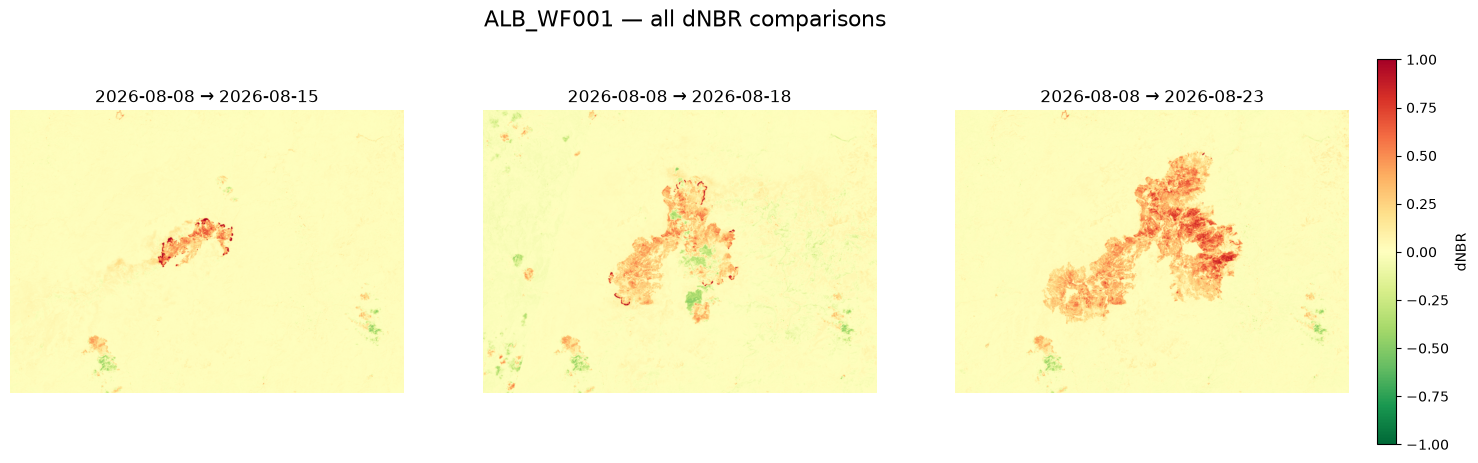

In [34]:
dnbr_items = find_dnbr_items()

if not dnbr_items:
    print("No dNBR images found.")
else:
    n = len(dnbr_items)
    ncols = 3
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
    axes = np.atleast_1d(axes).reshape(-1)
    last_im = None

    for ax, (label, filepath) in zip(axes, dnbr_items):
        with rasterio.open(filepath) as src:
            image = src.read(1).astype(float)
            if src.nodata is not None:
                image[image == src.nodata] = np.nan

        last_im = ax.imshow(image, cmap="RdYlGn_r", vmin=-1, vmax=1)
        ax.set_title(label)
        ax.axis("off")

    for ax in axes[len(dnbr_items):]:
        ax.axis("off")

    if last_im is not None:
        cbar = fig.colorbar(
            last_im,
            ax=axes[:len(dnbr_items)],
            fraction=0.02,
            pad=0.02,
        )
        cbar.set_label("dNBR")

    plt.suptitle(f"{PROJECT_NAME} — all dNBR comparisons", fontsize=16)
    plt.show()

## 20. Optional: create a ZIP archive of the project

This archives only the project directory under `mystorage/Sentinel-2`, not the shared download cache.

In [35]:
zip_base = BASE_FOLDER / PROJECT_NAME

zip_file = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=str(PROJECT_FOLDER),
)

print("Created:", zip_file)

Created: C:\iamo\fire-school\mystorage\Sentinel-2\ALB_WF001.zip


# Processing logic recap

The key distinction from the supplied overpass notebook is intentional:

- **This notebook:** searches the catalogue → derives unique dates → processes selected dates using a full-day interval and `LEAST_CC` mosaicking.
- **Overpass notebook:** searches the catalogue → groups tiles by satellite/orbit/date → constructs a narrow timestamp window for each overpass → mosaics only that overpass.

Everything after acquisition selection follows the same fire-analysis idea: consistent composites, B12/B8A/NBR, interactive inspection, pre-fire selection, and dNBR comparison.